# Student Performance Analysis
Grouped bar charts, box plots, scatter plots, correlation heatmap and an equity report.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("StudentsPerformance.csv")
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [ ]:
df.shape

(1000, 8)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [ ]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
score_column = ['math score', 'reading score', 'writing score']
df[score_column].describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
df['Total Score'] = df['math score'] + df['reading score'] + df['writing score']
df['percentage'] = df['Total Score'] / 300 * 100
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,percentage
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


## 1. Grouped bar charts
Average score for each parental education level, split by lunch type.

In [ ]:
edu_order = ['some high school', 'high school', 'some college',
             "associate's degree", "bachelor's degree", "master's degree"]

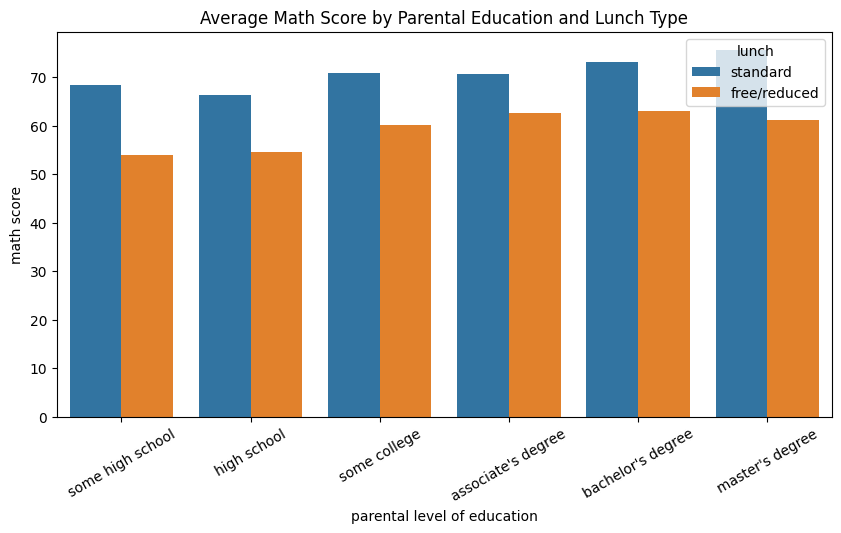

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x='parental level of education', y='math score', hue='lunch', data=df, order=edu_order, errorbar=None)
plt.title('Average Math Score by Parental Education and Lunch Type')
plt.xticks(rotation=30)
plt.show()

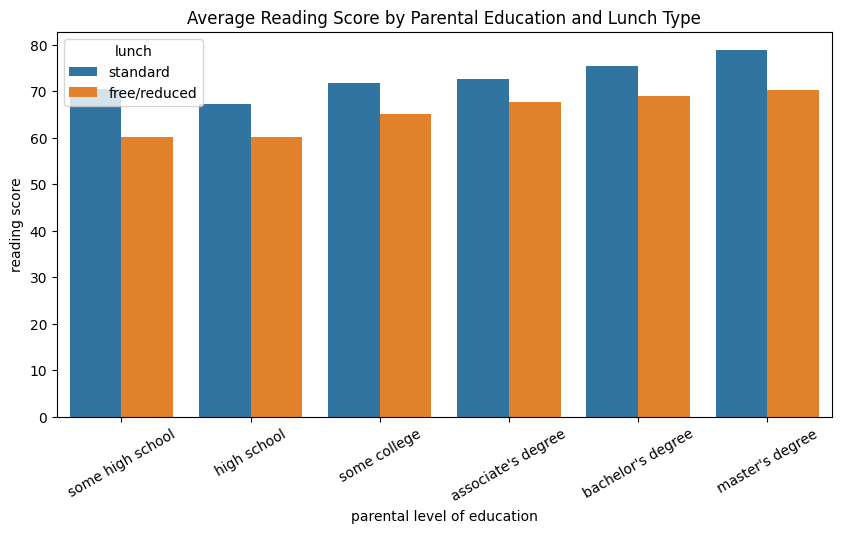

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x='parental level of education', y='reading score', hue='lunch', data=df, order=edu_order, errorbar=None)
plt.title('Average Reading Score by Parental Education and Lunch Type')
plt.xticks(rotation=30)
plt.show()

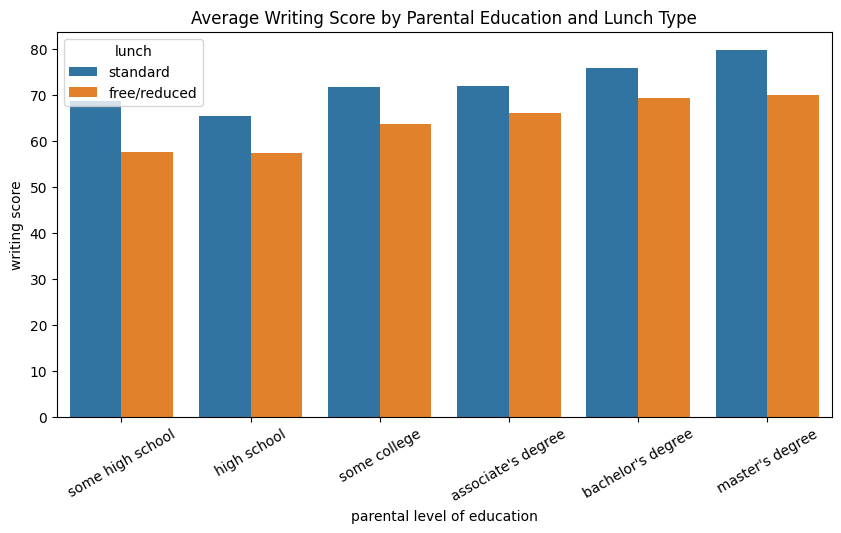

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x='parental level of education', y='writing score', hue='lunch', data=df, order=edu_order, errorbar=None)
plt.title('Average Writing Score by Parental Education and Lunch Type')
plt.xticks(rotation=30)
plt.show()

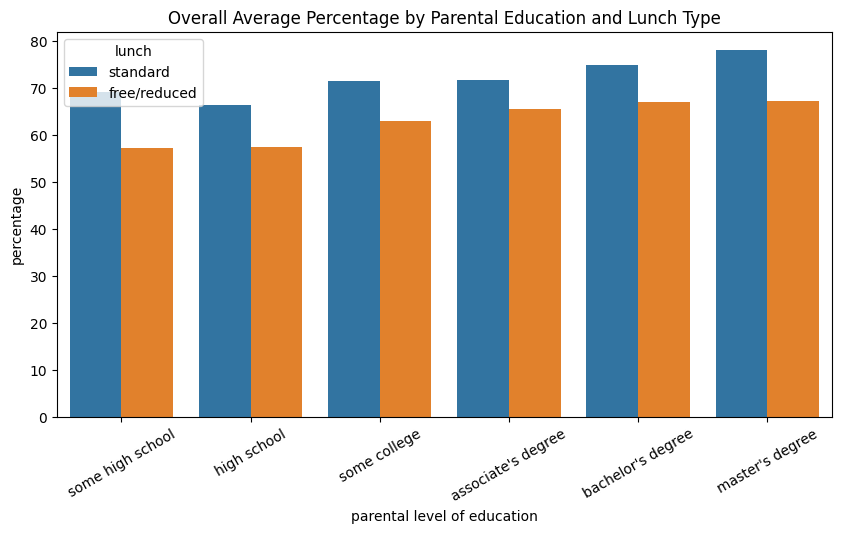

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x='parental level of education', y='percentage', hue='lunch', data=df, order=edu_order, errorbar=None)
plt.title('Overall Average Percentage by Parental Education and Lunch Type')
plt.xticks(rotation=30)
plt.show()

In [ ]:
df.groupby('lunch')[score_column + ['percentage']].mean()

,math score,reading score,writing score,percentage
lunch,,,,
free/reduced,58.921127,64.653521,63.022535,62.199061
standard,70.034109,71.654264,70.823256,70.837209


In [ ]:
df.groupby('parental level of education')[score_column + ['percentage']].mean()

,math score,reading score,writing score,percentage
parental level of education,,,,
associate's degree,67.882883,70.927928,69.896396,69.569069
bachelor's degree,69.389831,73.000000,73.381356,71.923729
high school,62.137755,64.704082,62.448980,63.096939
master's degree,69.745763,75.372881,75.677966,73.598870
some college,67.128319,69.460177,68.840708,68.476401
some high school,63.497207,66.938547,64.888268,65.108007


## 2. Box plots
Score spread for students who completed test preparation vs. those who did not.

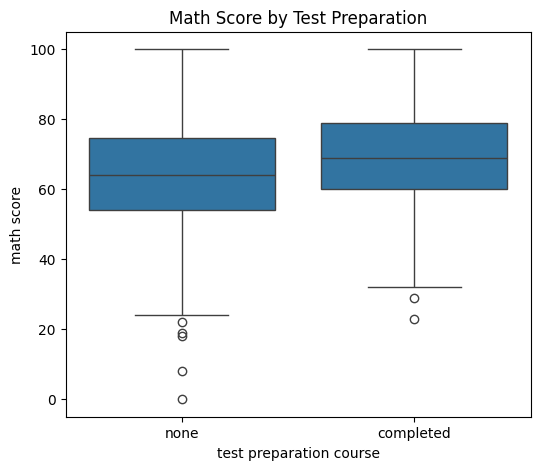

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='test preparation course', y='math score', data=df)
plt.title('Math Score by Test Preparation')
plt.show()

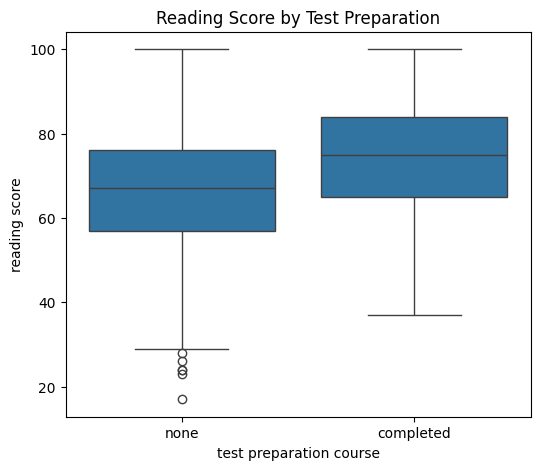

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='test preparation course', y='reading score', data=df)
plt.title('Reading Score by Test Preparation')
plt.show()

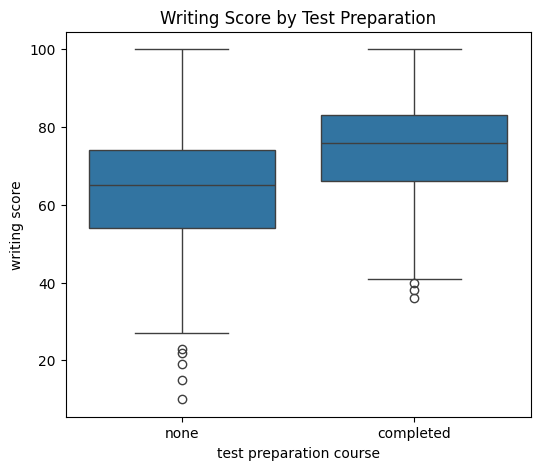

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='test preparation course', y='writing score', data=df)
plt.title('Writing Score by Test Preparation')
plt.show()

In [ ]:
df.groupby('test preparation course')[score_column].mean()

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


In [ ]:
df.groupby('test preparation course')[score_column].std()

,math score,reading score,writing score
test preparation course,,,
completed,14.444699,13.638384,13.375335
none,15.192376,14.463885,14.999661


In [ ]:
df.groupby('test preparation course')[score_column].var()

,math score,reading score,writing score
test preparation course,,,
completed,208.649336,186.005508,178.899582
none,230.808278,209.203972,224.989838


## 3. Scatter plots and correlation heatmap

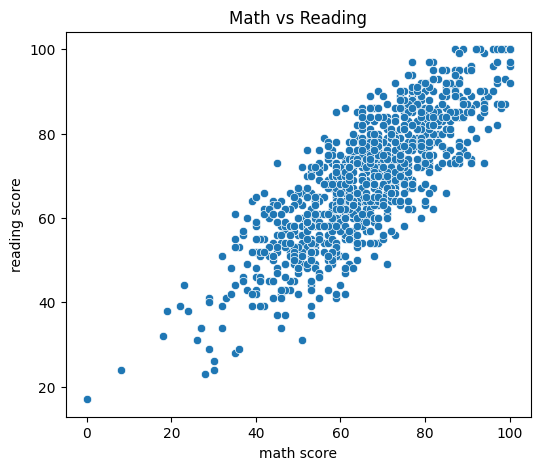

In [ ]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x='math score', y='reading score', data=df)
plt.title('Math vs Reading')
plt.show()

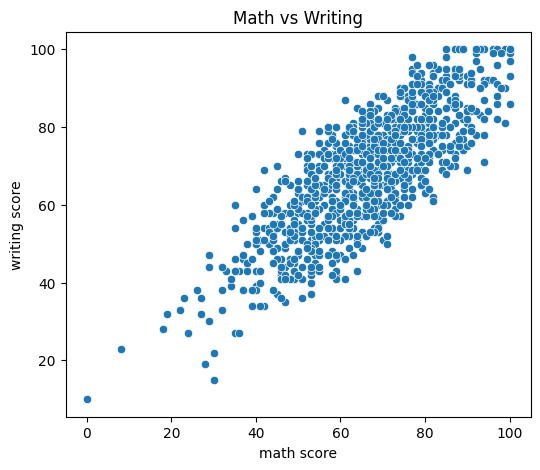

In [ ]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x='math score', y='writing score', data=df)
plt.title('Math vs Writing')
plt.show()

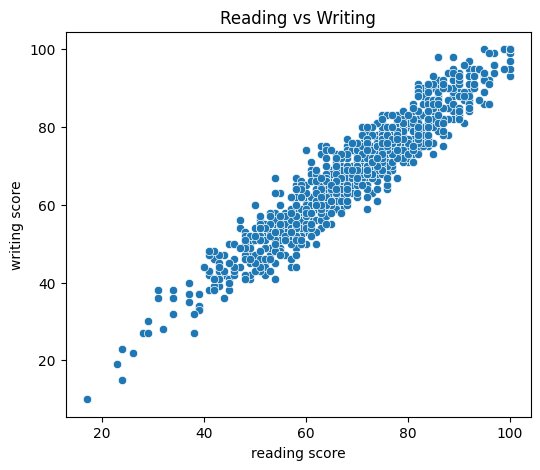

In [ ]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x='reading score', y='writing score', data=df)
plt.title('Reading vs Writing')
plt.show()

In [ ]:
df[score_column].corr()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


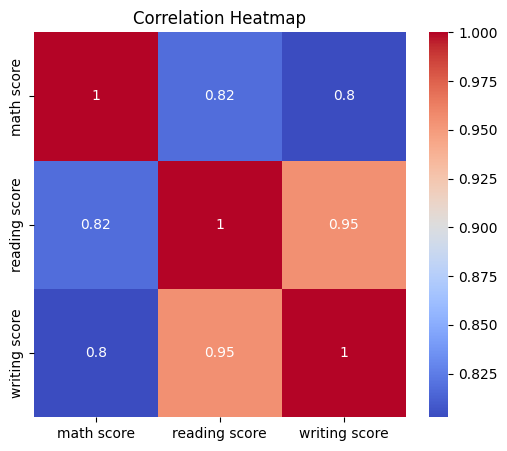

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[score_column].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()